# 03. Exploratory Data Analysis (EDA)

**Objective:**  
Explore cleaned landmark data to:
- Understand class distribution  
- Study feature behavior  
- Analyze correlations  
- Extract insights for modeling  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")


In [2]:
DATA_PATH = Path("../data/train_cleaned.csv")
df = pd.read_csv(DATA_PATH)

print("✅ Clean training dataset loaded")
print("Dataset shape:", df.shape)


✅ Clean training dataset loaded
Dataset shape: (13130, 43)


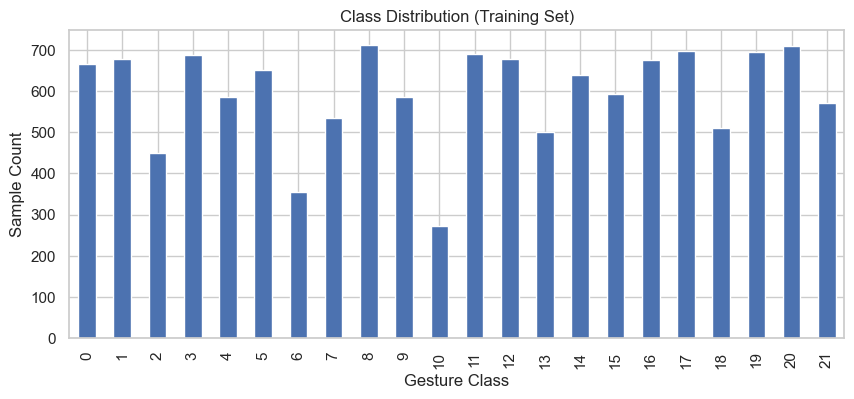

📊 Class distribution plotted


In [3]:
plt.figure(figsize=(10, 4))
df["class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution (Training Set)")
plt.xlabel("Gesture Class")
plt.ylabel("Sample Count")
plt.show()

print("📊 Class distribution plotted")


In [4]:
print("📈 Statistical summary:")
df.describe().T


📈 Statistical summary:


,count,mean,std,min,25%,50%,75%,max
0,13130.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,13130.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,13130.0,-2.814031e-17,1.000038,-2.981809,-0.823685,-0.193065,0.888453,3.194707
3,13130.0,2.150569e-15,1.000038,-2.716084,-0.685137,-0.183312,0.527703,3.369103
4,13130.0,-3.495892e-16,1.000038,-2.751891,-0.824171,-0.170371,0.840745,2.788488
5,13130.0,-7.094604e-16,1.000038,-2.156540,-0.661694,-0.271642,0.521101,2.752049
6,13130.0,-1.063379e-16,1.000038,-2.372157,-0.807784,-0.095799,0.823587,2.537247
7,13130.0,7.971283e-16,1.000038,-1.891397,-0.661302,-0.290319,0.575590,2.647029
8,13130.0,1.125612e-16,1.000038,-1.978854,-0.814313,-0.042440,0.812052,2.138389
9,13130.0,3.148467e-15,1.000038,-1.451293,-0.693550,-0.292689,0.634187,2.395709


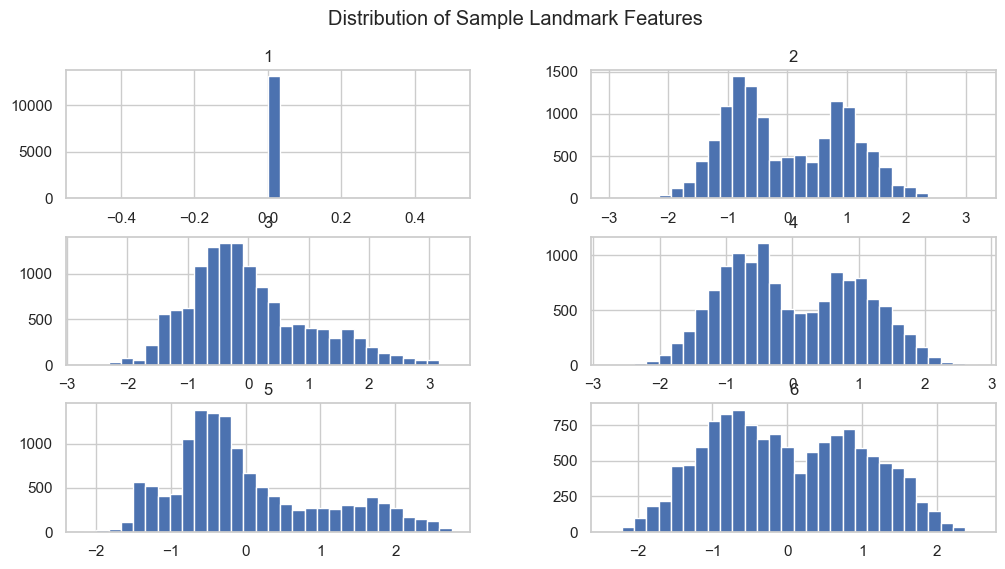

📊 Feature distributions visualized


In [5]:
sample_features = df.columns[1:7]

df[sample_features].hist(bins=30, figsize=(12, 6))
plt.suptitle("Distribution of Sample Landmark Features")
plt.show()

print("📊 Feature distributions visualized")


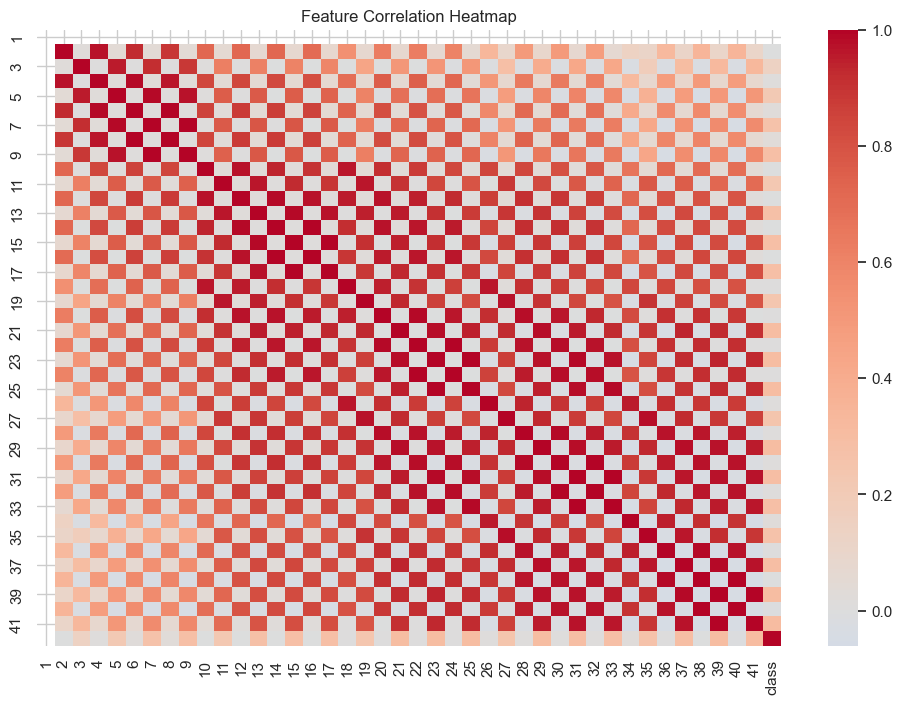

🔗 Correlation analysis completed


In [6]:
plt.figure(figsize=(12, 8))
corr = df.iloc[:, 1:].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

print("🔗 Correlation analysis completed")


In [7]:
class_means = df.groupby("class").mean()
print("📌 Per-class mean feature values (sample):")
class_means.iloc[:, :6]


📌 Per-class mean feature values (sample):


,0,1,2,3,4,5
class,,,,,,
0,0.0,0.0,0.014587,-0.135608,0.025074,-0.359636
1,0.0,0.0,0.103349,-1.091741,0.102208,-1.128338
2,0.0,0.0,0.143275,0.100086,0.106835,-0.055360
3,0.0,0.0,0.067997,-0.022186,0.040494,0.213781
4,0.0,0.0,0.072158,-0.962322,0.067595,-1.040770
5,0.0,0.0,-0.027360,0.408858,-0.082139,0.164591
6,0.0,0.0,-0.020700,0.861063,-0.049318,0.996551
7,0.0,0.0,0.150846,-0.238866,0.144895,-0.276138
8,0.0,0.0,-1.015645,-0.340315,-0.929665,-0.538831


Columns in dataset:
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', 'class'],
      dtype='object')

Detected label column: class


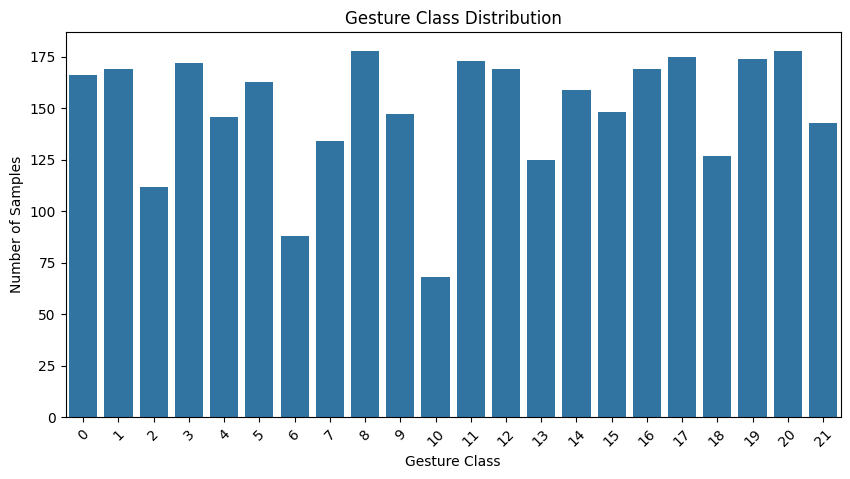

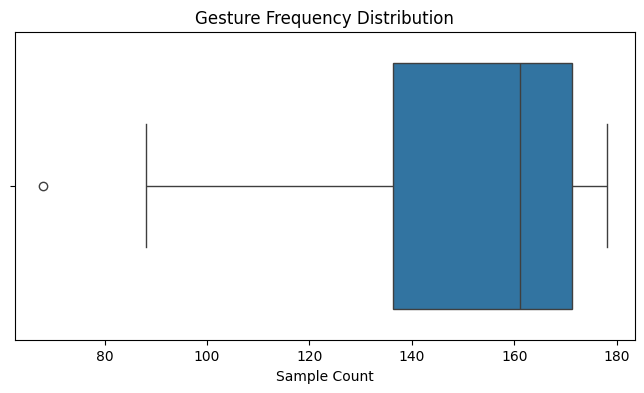

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../notebooks_data/test_cleaned.csv")

# Print columns (already done by you, kept for clarity)
print("Columns in dataset:")
print(df.columns)

# -------------------------------
# Automatically detect label column
# -------------------------------
possible_label_columns = ["label", "gesture", "class", "target", "sign"]

label_col = None
for col in possible_label_columns:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("No label/gesture column found in dataset")

print(f"\nDetected label column: {label_col}")

# -------------------------------
# 1. Class Distribution (EDA Visual)
# -------------------------------
plt.figure(figsize=(10,5))
sns.countplot(x=label_col, data=df)
plt.title("Gesture Class Distribution")
plt.xlabel("Gesture Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 2. Percentage Distribution Table
# -------------------------------
class_percentage = (
    df[label_col]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

class_percentage.columns = ["Gesture Class", "Percentage (%)"]
class_percentage

# -------------------------------
# 3. Class Imbalance Boxplot
# -------------------------------
plt.figure(figsize=(8,4))
sns.boxplot(x=df[label_col].value_counts().values)
plt.title("Gesture Frequency Distribution")
plt.xlabel("Sample Count")
plt.show()
